<a href="https://colab.research.google.com/github/sennagh/Chapter-9-XGBoost-Hyperparameter-Tunning/blob/main/medical_cost_prediction_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving medical_cost_prediction_dataset.csv to medical_cost_prediction_dataset (5).csv
K-FOLD mean val_loss: 17412112.4


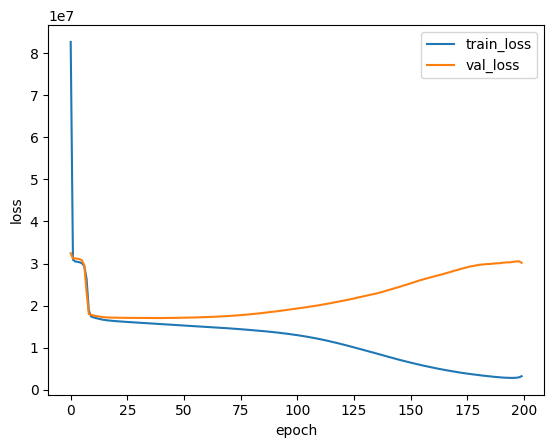

TEST: {'loss': 28637230.0, 'compile_metrics': 3459.216064453125}


In [ ]:
!pip -q install scikeras

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt
from scikeras.wrappers import KerasRegressor

from google.colab import files
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])
df.head()

df = df.sample(frac=1).reset_index(drop=True)

X = df.iloc[:, :-2].copy()
y = df.iloc[:, -2:].apply(pd.to_numeric, errors="coerce")

mask = y.notna().all(axis=1)
X, y = X.loc[mask].reset_index(drop=True), y.loc[mask].reset_index(drop=True)

num_cols = X.select_dtypes(include=[np.number]).columns
cat_cols = X.columns.difference(num_cols)

X[num_cols] = X[num_cols].apply(pd.to_numeric, errors="coerce")
X[num_cols] = X[num_cols].fillna(X[num_cols].median())
X[cat_cols] = X[cat_cols].astype("string").fillna("UNK")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, shuffle=False
)

y_train_combo = y_train.mean(axis=1).values.astype("float32")

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

Xt_train = preprocess.fit_transform(X_train)
Xt_test  = preprocess.transform(X_test)

k = min(50, Xt_train.shape[1])
selector = SelectKBest(score_func=f_regression, k=k)
Xt_train_sel = selector.fit_transform(Xt_train, y_train_combo)
Xt_test_sel  = selector.transform(Xt_test)

inp = keras.Input(shape=(Xt_train_sel.shape[1],), name="features")
x = layers.Dense(512, activation="relu")(inp)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dense(128, activation="relu")(x)
out = layers.Dense(2, name="costs")(x)
model = keras.Model(inp, out)
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

history = model.fit(
    Xt_train_sel, y_train.values.astype("float32"),
    validation_split=0.10,
    epochs=200,
    verbose=0,
    shuffle=False
)

kf = KFold(n_splits=5, shuffle=False)

val_losses = []
for tr_idx, va_idx in kf.split(X_train):
    Xtr, Xva = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    ytr, yva = y_train.iloc[tr_idx], y_train.iloc[va_idx]

    ytr_combo = ytr.mean(axis=1).values.astype("float32")

    prep_f = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ],
        remainder="drop"
    )
    Xt_tr = prep_f.fit_transform(Xtr)
    Xt_va = prep_f.transform(Xva)

    kf_k = min(50, Xt_tr.shape[1])
    sel_f = SelectKBest(score_func=f_regression, k=kf_k)
    Xt_tr = sel_f.fit_transform(Xt_tr, ytr_combo)
    Xt_va = sel_f.transform(Xt_va)

    inp_f = keras.Input(shape=(Xt_tr.shape[1],))
    x_f = layers.Dense(512, activation="relu")(inp_f)
    x_f = layers.Dense(256, activation="relu")(x_f)
    x_f = layers.Dense(128, activation="relu")(x_f)
    out_f = layers.Dense(2)(x_f)

    m = keras.Model(inp_f, out_f)
    m.compile(optimizer="adam", loss="mse", metrics=["mae"])

    h = m.fit(
        Xt_tr, ytr.values.astype("float32"),
        validation_data=(Xt_va, yva.values.astype("float32")),
        epochs=80,
        verbose=0,
        shuffle=False
    )
    val_losses.append(h.history["val_loss"][-1])

print("K-FOLD mean val_loss:", float(np.mean(val_losses)))

plt.figure()
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend()
plt.show()

test_metrics = model.evaluate(Xt_test_sel, y_test.values.astype("float32"), verbose=0)
print("TEST:", dict(zip(model.metrics_names, test_metrics)))

In [ ]:
import tensorflow as tf

opts = [name for name in dir(tf.keras.optimizers)
        if name[0].isupper() and "Optimizer" not in name and "experimental" not in name.lower()]

print(opts)

['Adadelta', 'Adafactor', 'Adagrad', 'Adam', 'AdamW', 'Adamax', 'Ftrl', 'Lamb', 'Lion', 'Muon', 'Nadam', 'RMSprop', 'SGD']


In [ ]:
# Functional
inp = keras.Input(shape=(Xt_train_sel.shape[1],), name="features")
x = layers.Dense(128, activation="relu")(inp)
x = layers.Dense(64, activation="swish")(x)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dense(16, activation="elu")(x)
#x = layers.Dense(8, activation="mish")(x)
out = layers.Dense(2, name="costs")(x)
model = keras.Model(inp, out)
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.fit(
        Xt_tr, ytr.values.astype("float32"),
        epochs=80,
        verbose=0,
        shuffle=False
    )

test_metrics = model.evaluate(Xt_test_sel, y_test.values.astype("float32"), verbose=0)
print("TEST:", dict(zip(model.metrics_names, test_metrics)))

TEST: {'loss': 16617667.0, 'compile_metrics': 2829.660888671875}
